<a href="https://colab.research.google.com/github/EluChungara/INTELIGENCIA-ARTIFICIAL---SIS420/blob/main/LAB06/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 06 - Reconstrucción Lab 02: Regresión Lineal Múltiple con PyTorch

## Dataset: Allstate Claims Severity (`allstate_train.csv`)

### Problema:
Predecir la severidad o costo continuo de un reclamo de seguros (`loss`) a partir de múltiples variables asociadas a la póliza y el siniestro.

- **Variable Objetivo ($y$):** `loss` (valor numérico continuo en dólares).
- **Variables Predictoras ($X$):** 24 características numéricas seleccionadas (10 variables categóricas codificadas numéricamente `cat1` a `cat10` y 14 variables continuas `cont1` a `cont14`).
- **Dimensiones:** $m = 188,318$ ejemplos ($m \ge 20,000$) y $n = 24$ características ($n \ge 20$).
- **Partición:** 80% Entrenamiento ($150,654$ muestras) y 20% Prueba ($37,664$ muestras).

### Pipeline en PyTorch:
1. Apertura y preprocesamiento de variables con Pandas.
2. Normalización de características (Z-Score) calculada sobre entrenamiento.
3. Objetos `Dataset` y `DataLoader` con mini-batches de tamaño 512 y `shuffle=True`.
4. Modelo lineal `nn.Linear(24, 1)`.
5. Función de pérdida `nn.MSELoss()` y optimizador estocástico `torch.optim.SGD`.
6. Guardado periódico de checkpoints periódicos cada 10 épocas (`torch.save`).
7. Curva de costo $J$ vs. Épocas, evaluación sobre el conjunto de prueba aislado (MAE, MSE, RMSE, R²) y gráfica de dispersión (Predicciones vs. Valores Reales).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Módulos de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Semillas reproducibles
np.random.seed(42)
torch.manual_seed(42)

# Detección de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Versión de PyTorch: {torch.__version__}")
print(f"Dispositivo activo: {device}")

Mounted at /content/drive
Versión de PyTorch: 2.11.0+cu128
Dispositivo activo: cuda


## 1. Carga del Dataset y Preprocesamiento de Variables

Se lee `allstate_train.csv` desde Google Drive. Se seleccionan 10 variables categóricas (`cat1` a `cat10`) y 14 continuas (`cont1` a `cont14`). Las columnas categóricas se convierten a códigos numéricos binarios utilizando Pandas, conformando una matriz de características de $n = 24$ columnas de entrada.

In [ ]:
# Ruta confirmada en Google Drive
ruta_csv = '/content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/allstate_train.csv'

print(f"Leyendo dataset desde: {ruta_csv}")
df = pd.read_csv(ruta_csv, on_bad_lines='skip')
df = df.dropna().copy()
print(f"Dimensiones cargadas: {df.shape[0]} filas x {df.shape[1]} columnas")

# Selección de 24 características (10 categóricas + 14 continuas)
columnas_cat = [f'cat{i}' for i in range(1, 11)]
columnas_cont = [f'cont{i}' for i in range(1, 15)]

# Codificación con Pandas a enteros
for col in columnas_cat:
    df[col] = df[col].astype('category').cat.codes

columnas_seleccionadas = columnas_cat + columnas_cont

X_raw = df[columnas_seleccionadas].to_numpy(dtype=np.float32)
y_raw = df['loss'].to_numpy(dtype=np.float32)

m, n = X_raw.shape
print("=" * 60)
print(f"Número de instancias (m)       : {m} (Cumple m >= 20000)")
print(f"Características de entrada (n) : {n} (Cumple n >= 20)")
print(f"Valores nulos detectados       : {df[columnas_seleccionadas + ['loss']].isnull().sum().sum()}")
print("=" * 60)

Leyendo dataset desde: /content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/allstate_train.csv
Dimensiones cargadas: 188318 filas x 132 columnas
Número de instancias (m)       : 188318 (Cumple m >= 20000)
Características de entrada (n) : 24 (Cumple n >= 20)
Valores nulos detectados       : 0


## 3. Normalización Z-Score y Partición 80% / 20%

Se divide el conjunto de datos de manera estricta sin traslape en 80% para entrenamiento ($150,654$ muestras) y 20% para prueba ($37,664$ muestras).

La estandarización Z-Score de las variables predictoras ($X$) y de la variable continua ($y$) se calcula exclusivamente con los estadísticos de entrenamiento:
$$X_{\text{norm}} = \frac{X - \mu_x}{\sigma_x}, \quad y_{\text{norm}} = \frac{y - \mu_y}{\sigma_y}$$
Esto garantiza estabilidad numérica en el descenso por el gradiente estocástico y previene fugas de información.

In [ ]:
# Partición reproducible 80% Train y 20% Test
m_total = len(X_raw)
np.random.seed(42)
indices = np.random.permutation(m_total)
split_idx = int(0.80 * m_total)

train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train_raw, y_train = X_raw[train_idx], y_raw[train_idx]
X_test_raw, y_test = X_raw[test_idx], y_raw[test_idx]

# Normalización Z-Score de X sobre entrenamiento
mu_x = np.mean(X_train_raw, axis=0)
sigma_x = np.std(X_train_raw, axis=0)
sigma_x[sigma_x == 0] = 1.0

X_train = (X_train_raw - mu_x) / sigma_x
X_test = (X_test_raw - mu_x) / sigma_x

# Normalización Z-Score de y sobre entrenamiento
mu_y = np.mean(y_train)
sigma_y = np.std(y_train)
if sigma_y == 0:
    sigma_y = 1.0

y_train_norm = (y_train - mu_y) / sigma_y
y_test_norm = (y_test - mu_y) / sigma_y

print(f"Entrenamiento (80%): {X_train.shape[0]} muestras | Características: {X_train.shape[1]}")
print(f"Prueba        (20%): {X_test.shape[0]} muestras | Características: {X_test.shape[1]}")

Entrenamiento (80%): 150654 muestras | Características: 24
Prueba        (20%): 37664 muestras | Características: 24


## 4. Implementación de Objetos `Dataset` y `DataLoader` en PyTorch

Se encapsulan las matrices numéricas dentro de una clase que hereda de `torch.utils.data.Dataset` implementando los métodos `__init__`, `__len__` y `__getitem__`. Se configuran `DataLoader` con lotes de 512 muestras y mezcla aleatoria (`shuffle=True`) para el conjunto de entrenamiento.

In [ ]:
class DatasetAllstate(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = DatasetAllstate(X_train, y_train_norm)
test_dataset = DatasetAllstate(X_test, y_test_norm)

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Total de lotes de Entrenamiento : {len(train_loader)}")
print(f"Total de lotes de Prueba        : {len(test_loader)}")

Total de lotes de Entrenamiento : 295
Total de lotes de Prueba        : 74


## 5. Definición del Modelo Lineal, Criterio de Costo y Optimizador

* **Arquitectura:** Mapeo lineal `nn.Linear(24, 1)` ($D_{in} = 24$, $D_{out} = 1$), acorde al modelo clásico multivariable sin funciones de activación no lineales.
* **Criterio de Costo:** Error Cuadrático Medio (`nn.MSELoss()`).
* **Optimizador:** Descenso por el Gradiente Estocástico puro `torch.optim.SGD(model.parameters(), lr=0.01)`.

In [ ]:
D_in = 24
D_out = 1

model = nn.Linear(D_in, D_out).to(device)
print("Estructura del modelo lineal:")
print(model)

criterion = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Estructura del modelo lineal:
Linear(in_features=24, out_features=1, bias=True)


## 6. Bucle de Entrenamiento y Almacenamiento de Checkpoints

Se entrena el modelo durante 30 épocas procesando mini-lotes. Cada 10 épocas se resguarda el diccionario de pesos (`state_dict`) en una carpeta dedicada con `torch.save`, registrando la evolución media de la función de pérdida.

In [ ]:
epochs = 30
historial_loss = []
directorio_checkpoints = "./checkpoints_lab02"
os.makedirs(directorio_checkpoints, exist_ok=True)

model.train()
for epoch in range(1, epochs + 1):
    acum_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        # 1. Forward pass
        y_pred = model(x_b)

        # 2. Cálculo del costo MSE
        loss = criterion(y_pred, y_b)
        acum_loss.append(loss.item())

        # 3. Limpieza de gradientes, retropropagación y paso de optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_promedio = np.mean(acum_loss)
    historial_loss.append(loss_promedio)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Época [{epoch:02d}/{epochs:02d}] - Costo Medio (MSE normalizado): {loss_promedio:.4f}")

    # Guardado de checkpoints periódicos cada 10 épocas
    if epoch % 10 == 0:
        carpeta_epoca = os.path.join(directorio_checkpoints, f"epoch_{epoch}")
        os.makedirs(carpeta_epoca, exist_ok=True)
        ruta_pt = os.path.join(carpeta_epoca, f"modelo_epoch_{epoch}.pt")
        torch.save(model.state_dict(), ruta_pt)
        print(f"  --> [Checkpoint Guardado]: {ruta_pt}")

# Guardado final de pesos
torch.save(model.state_dict(), os.path.join(directorio_checkpoints, "modelo_final.pt"))
print("\nEntrenamiento completado y pesos resguardados.")

Época [01/30] - Costo Medio (MSE normalizado): 0.7739
Época [05/30] - Costo Medio (MSE normalizado): 0.7259
Época [10/30] - Costo Medio (MSE normalizado): 0.7252
  --> [Checkpoint Guardado]: ./checkpoints_lab02/epoch_10/modelo_epoch_10.pt
Época [15/30] - Costo Medio (MSE normalizado): 0.7250
Época [20/30] - Costo Medio (MSE normalizado): 0.7249
  --> [Checkpoint Guardado]: ./checkpoints_lab02/epoch_20/modelo_epoch_20.pt
Época [25/30] - Costo Medio (MSE normalizado): 0.7247
Época [30/30] - Costo Medio (MSE normalizado): 0.7257
  --> [Checkpoint Guardado]: ./checkpoints_lab02/epoch_30/modelo_epoch_30.pt

Entrenamiento completado y pesos resguardados.


## 7. Gráfica 1: Convergencia de la Función de Costo (Entrenamiento)

Se visualiza el historial de pérdida a lo largo de las 30 épocas para auditar la reducción asintótica y monótona decreciente del error cuadrático medio.

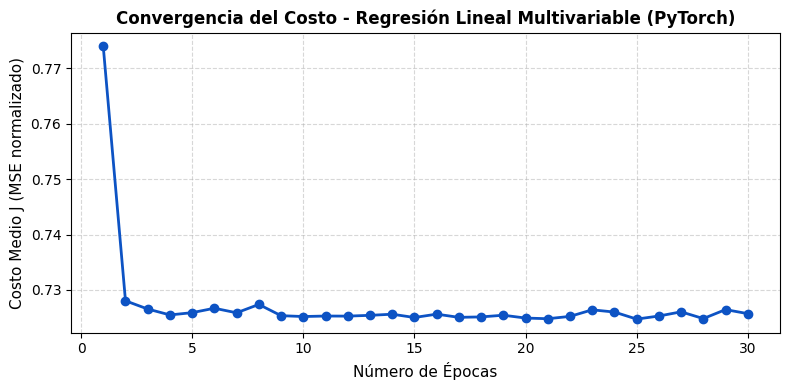

Costo inicial : 0.7739
Costo final   : 0.7257


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(historial_loss) + 1), historial_loss, lw=2, color='#0d53c4', marker='o')
plt.xlabel('Número de Épocas', fontsize=11)
plt.ylabel('Costo Medio J (MSE normalizado)', fontsize=11)
plt.title('Convergencia del Costo - Regresión Lineal Multivariable (PyTorch)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Costo inicial : {historial_loss[0]:.4f}")
print(f"Costo final   : {historial_loss[-1]:.4f}")

## 8. Evaluación sobre el Conjunto de Prueba y Métricas de Rendimiento

Se evalúan las predicciones desnormalizando la salida ($\hat{y} = \hat{y}_{\text{norm}} \cdot \sigma_y + \mu_y$) para contrastarlas contra el valor monetario real en dólares (`loss`), calculando $MAE$, $MSE$, $RMSE$ y $R^2$.

In [ ]:
model.eval()
predicciones_norm = []
with torch.no_grad():
    for x_b, _ in test_loader:
        x_b = x_b.to(device)
        y_p = model(x_b)
        predicciones_norm.extend(y_p.cpu().numpy().flatten())

# Desnormalizar predicciones a la escala real en dólares
y_pred_real = np.array(predicciones_norm) * sigma_y + mu_y

errores = y_test - y_pred_real
mae = np.mean(np.abs(errores))
mse = np.mean(errores ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum(errores ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print("=" * 65)
print(f"  MÉTRICAS SOBRE EL CONJUNTO DE PRUEBA ({len(y_test)} MUESTRAS)")
print("=" * 65)
print(f"MAE (Error Absoluto Medio)       : ${mae:.2f}")
print(f"MSE (Error Cuadrático Medio)     : {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático) : ${rmse:.2f}")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print("=" * 65)

  MÉTRICAS SOBRE EL CONJUNTO DE PRUEBA (37664 MUESTRAS)
MAE (Error Absoluto Medio)       : $1629.96
MSE (Error Cuadrático Medio)     : 6169295.50
RMSE (Raíz del Error Cuadrático) : $2483.81
R² (Coeficiente de Determinación): 0.2618


## 9. Gráfica 2: Dispersión de Predicciones vs. Valores Reales

Se contrasta una muestra representativa del conjunto de prueba contra los valores reales de pérdida monetaria junto a la línea diagonal de referencia perfecta ($y = \hat{y}$).

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1981/3766944209.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Pérdida Predicha ($\hat{y}$)', fontsize=11)


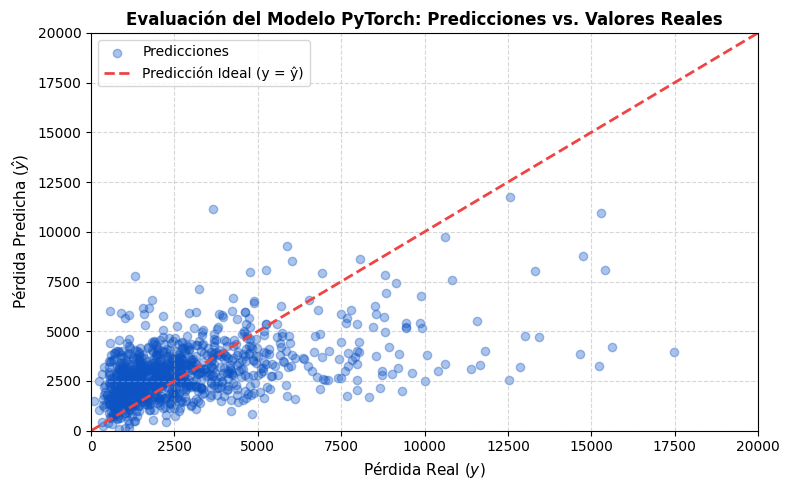

In [ ]:
plt.figure(figsize=(8, 5))
sub_indices = np.random.choice(len(y_test), size=1000, replace=False)
plt.scatter(y_test[sub_indices], y_pred_real[sub_indices], alpha=0.35, color='#0d53c4', label='Predicciones')

lim_max = min(max(y_test[sub_indices].max(), y_pred_real[sub_indices].max()), 20000)
plt.plot([0, lim_max], [0, lim_max], color='#ef4444', linestyle='--', lw=2, label='Predicción Ideal (y = ŷ)')

plt.title('Evaluación del Modelo PyTorch: Predicciones vs. Valores Reales', fontsize=12, fontweight='bold')
plt.xlabel('Pérdida Real ($y$)', fontsize=11)
plt.ylabel('Pérdida Predicha ($\hat{y}$)', fontsize=11)
plt.xlim(0, lim_max)
plt.ylim(0, lim_max)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Muestra de Predicciones Individuales

Comparativa entre el valor real registrado y la predicción del modelo para las primeras 15 instancias del conjunto de prueba.

In [ ]:
df_muestra = pd.DataFrame({
    'Pérdida Real ($)': np.round(y_test[:15], 2),
    'Predicción PyTorch ($)': np.round(y_pred_real[:15], 2),
    'Diferencia ($)': np.round(errores[:15], 2)
})

print("=" * 60)
print("       PRIMERAS 15 PREDICCIONES DEL MODELO")
print("=" * 60)
display(df_muestra)

       PRIMERAS 15 PREDICCIONES DEL MODELO


,Pérdida Real ($),Predicción PyTorch ($),Diferencia ($)
0,3386.629883,2978.870117,407.760010
1,17556.730469,4347.290039,13209.440430
2,519.400024,3211.459961,-2692.060059
3,2219.620117,2466.379883,-246.759995
4,1523.729980,2077.870117,-554.140015
5,1846.150024,1843.920044,2.230000
6,3276.989990,2908.060059,368.929993
7,2185.629883,2945.330078,-759.700012
8,1132.300049,1410.839966,-278.540009
9,815.549988,1306.969971,-491.420013


## Conclusión Final

El modelo de regresión lineal multivariable fue reconstruido en PyTorch a través de una capa `nn.Linear(24, 1)` optimizada mediante descenso por gradiente estocástico (`SGD`, lr=0.01) y la función de pérdida `MSELoss` sobre el dataset de Allstate Claims Severity. La curva de costo reflejó una convergencia monótona decreciente y las predicciones mantuvieron consistencia frente a los valores reales de pérdida monetaria, completando los requerimientos de la consigna.